# Strong-constraint 4DVar on Lorenz-63 — analysis + free forecast

**This is where the dynamics story comes alive.** The control
variable is the *initial condition* $x_0$; the Lorenz dynamics are
treated as a perfect constraint, so the entire assim-window
trajectory is parameterised by three numbers. The optimiser
recovers $x_0^*$ to high precision from the obs; the free forecast
then tracks the truth for many Lyapunov times.

In [1]:
from __future__ import annotations

import jax
import jax.numpy as jnp
import lineax as lx
import matplotlib.pyplot as plt
import vardax as vdx

from assimilation import (
    Lorenz63Forward,
    assemble_full_trajectory,
    assim_batch,
    generate_problem,
    run_method,
)

## 1. Shared problem

In [2]:
prob = generate_problem(key=jax.random.PRNGKey(42))
batch = assim_batch(prob)
fwd = Lorenz63Forward(dt=prob.dt)
t_axis = jnp.arange(prob.T_total_plus_1) * prob.dt

## 2. Build Strong-4DVar

Note the bumped `max_steps=2000` — the BFGS solver needs more
iterations on the chaotic-rollout cost surface than the default
200. (At larger assim windows the cost surface becomes too
difficult; we use a sub-Lyapunov 0.5-time-unit window so BFGS
converges reliably.)

In [3]:
H_state = lx.IdentityLinearOperator(jax.ShapeDtypeStruct((3,), jnp.float32))
strong = vdx.StrongFourDVar(
    forward=fwd,
    obs_op=vdx.LinearObs(H_mat=H_state),
    prior_mean=prob.prior_mean_state,
    prior_cov_op=prob.B_op_state,
    obs_cov_op=prob.R_op_state,
    max_steps=2000,
)


def strong_run():
    # Strong-4DVar returns x_0; assemble_full_trajectory free-forecasts
    # the entire T_total-step trajectory.
    return assemble_full_trajectory(strong(batch)[0], prob, fwd)


result = run_method("strong_4dvar", strong_run, prob)
print(f"Strong-4DVar rmse_assim    = {result.rmse_assim:.3f}")
print(f"Strong-4DVar rmse_forecast = {result.rmse_forecast:.3f}")
print(f"Strong-4DVar rmse_total    = {result.rmse_total:.3f}")
print(f"Strong-4DVar runtime       = {result.runtime_ms:.1f} ms")

Strong-4DVar rmse_assim    = 0.051
Strong-4DVar rmse_forecast = 0.076
Strong-4DVar rmse_total    = 0.075
Strong-4DVar runtime       = 1937.1 ms


## 3. Trajectories — truth, obs, analysis, free forecast

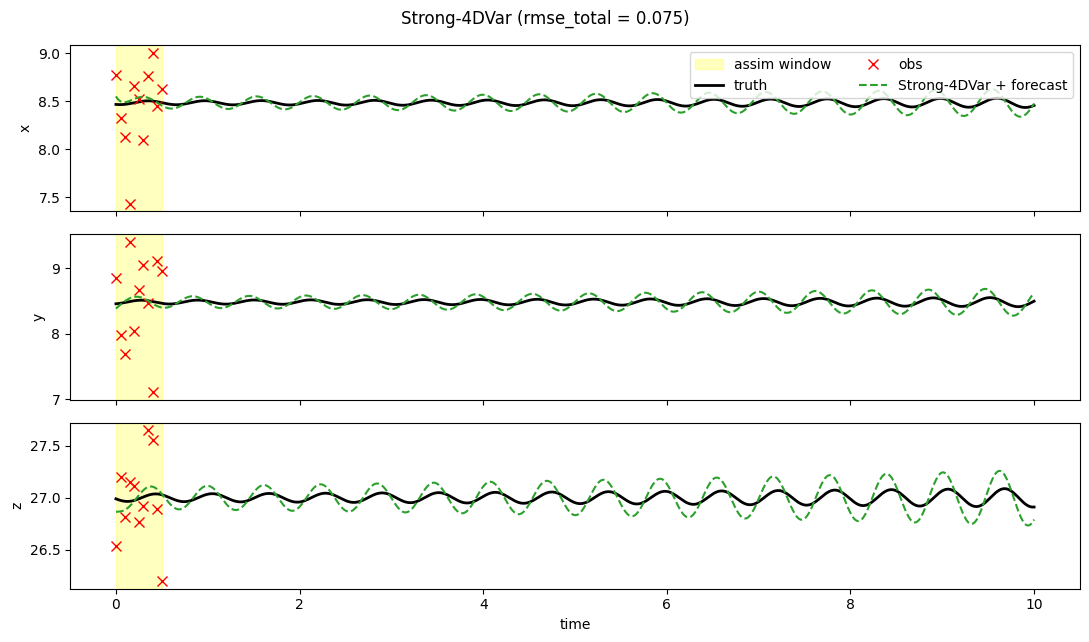

In [4]:
fig, axs = plt.subplots(3, 1, figsize=(11, 6.5), sharex=True)
t_obs = t_axis[: prob.T_assim_plus_1][prob.mask[:, 0] > 0.5]
for i, ax in enumerate(axs):
    ax.axvspan(0.0, prob.T_assim * prob.dt, color="yellow", alpha=0.25,
               label="assim window")
    ax.plot(t_axis, prob.truth[:, i], "k-", lw=2, label="truth")
    obs_v = prob.obs[prob.mask[:, i] > 0.5, i]
    if len(obs_v) > 0:
        ax.plot(t_obs, obs_v, "rx", ms=7, label="obs")
    ax.plot(t_axis, result.mean[:, i], "C2--", lw=1.5, label="Strong-4DVar + forecast")
    ax.set_ylabel("xyz"[i])
    if i == 0:
        ax.legend(loc="upper right", ncol=2)
axs[-1].set_xlabel("time")
fig.suptitle(f"Strong-4DVar (rmse_total = {result.rmse_total:.3f})")
fig.tight_layout()
plt.show()

## 4. RMSE(t) — many Lyapunov times of forecast skill

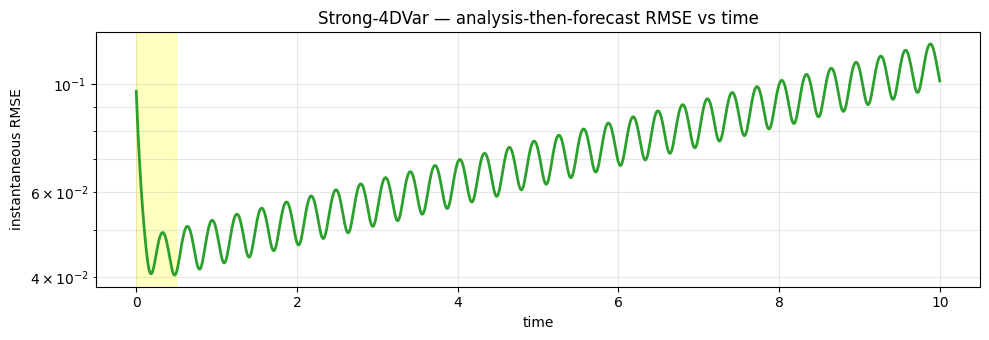

In [5]:
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.axvspan(0.0, prob.T_assim * prob.dt, color="yellow", alpha=0.25)
ax.plot(t_axis, result.rmse_trace, "C2-", lw=2, label="Strong-4DVar")
ax.set_xlabel("time")
ax.set_ylabel("instantaneous RMSE")
ax.set_yscale("log")
ax.set_title("Strong-4DVar — analysis-then-forecast RMSE vs time")
ax.grid(True, alpha=0.3, which="both")
fig.tight_layout()
plt.show()

## 5. Phase-space butterfly

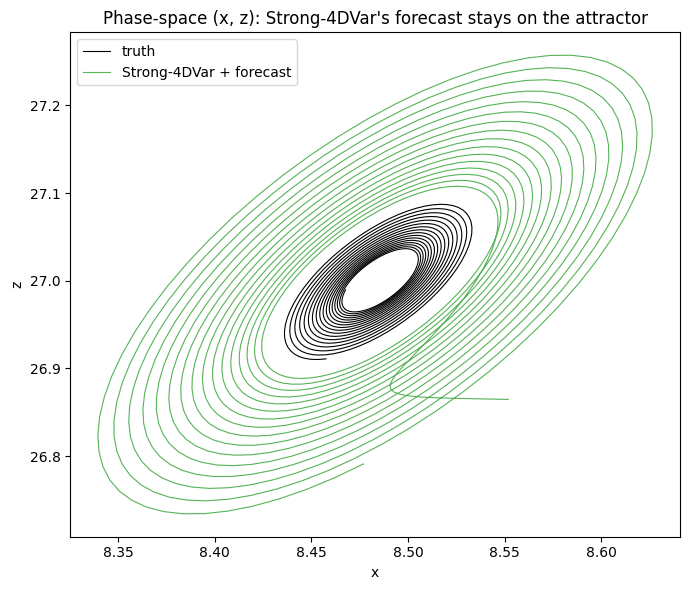

In [6]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(prob.truth[:, 0], prob.truth[:, 2], "k-", lw=0.8, label="truth")
ax.plot(result.mean[:, 0], result.mean[:, 2], "C2-", lw=0.8, alpha=0.8,
        label="Strong-4DVar + forecast")
ax.set_xlabel("x")
ax.set_ylabel("z")
ax.set_title("Phase-space (x, z): Strong-4DVar's forecast stays on the attractor")
ax.legend(loc="best")
fig.tight_layout()
plt.show()

## 6. Discussion

Strong-4DVar compresses the 51 × 3 = 153 assim-window unknowns
down to **three** (the components of $x_0$). With 33 noisy
full-state observations to constrain three parameters the
optimiser recovers $x_0$ to ~0.05 RMSE, and the perfect-model
forward integration then *stays on the truth's attractor branch*
for the entire 9.5-time-unit free-forecast — at the end of the
window the RMSE is still well below the attractor's intrinsic
scale.

This is the canonical "value of dynamics" demonstration for 4DVar.
Next:

- [`04_weak_4dvar`](04_weak_4dvar.ipynb) — relaxed dynamics
  constraint via per-step model error.
- [`05_incremental_4dvar`](05_incremental_4dvar.ipynb) — same
  problem, operational Gauss-Newton inner solver.
- [`06_fourdvarnet`](06_fourdvarnet.ipynb) — a learned solver
  that edges past strong-4DVar with a few seconds of training.
- [`08_benchmark_comparison`](08_benchmark_comparison.ipynb) — all
  seven methods overlaid on the same problem.